In [2]:
import csv
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:
#CODE I USED TO GENERATE PLOTS -- YOU WILL NEED TO MANUALLY GO IN AND CHANGE THE LINE FOLDER

In [3]:
C9 = ['RFTiALS', 'TJViALS', 'EGMiALS', 'LJXiALS']
Ctrl = ['AE8iCTR', 'ZKZiCTR', 'XH7iCTR', 'ADKiCTR', 'NK3iCTR']
SOD1 =  ['BFUiALS', 'KRCiALS', 'ZLMiALS', 'AFGiALS']
sALS = ['CS6EVH', 'CS6ULB', 'CS6WF5', 'CS8JGP']
genotype_dict = {}
for line in C9:
    genotype_dict[line] = "C9"
for line in Ctrl:
    genotype_dict[line] = "Ctrl"
for line in SOD1:
    genotype_dict[line] = "SOD1"
for line in sALS:
    genotype_dict[line] = "sALS"
line_list_dict = {}
line_list_dict["C9"] = C9
line_list_dict["Ctrl"] = Ctrl
line_list_dict["SOD1"] = SOD1
line_list_dict["sALS"] = sALS
genotype_list = ["C9", "Ctrl", "SOD1", "sALS"]

In [4]:
lines = C9+Ctrl + SOD1 + sALS

In [ ]:
#change this based on where your outputs are
OUTPUTS_FOLDER="/home/jholz/fraenkel_rotation/testing_mcbert_final"

['SOD1', 'C9', 'Ctrl', 'C9', 'C9', 'SOD1', 'SOD1', 'Ctrl', 'Ctrl', 'sALS', 'SOD1', 'SOD1', 'SOD1', 'sALS', 'sALS', 'C9', 'SOD1']
['C9', 'C9', 'C9', 'C9', 'Ctrl', 'Ctrl', 'Ctrl', 'Ctrl', 'Ctrl', 'SOD1', 'SOD1', 'SOD1', 'SOD1', 'sALS', 'sALS', 'sALS', 'sALS']


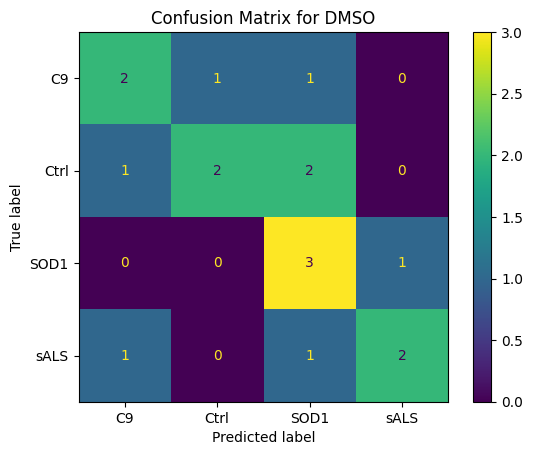

In [ ]:
#change perturbation to generate graphs
perturbation="DMSO"
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
for line in lines:
    LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
    PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
    predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
    predicted_genotype= predictions[-1:]["prediction"].item()
    if(predicted_genotype=="sALS with NuP defects"):
        predicted_genotype= "sALS"
    predicted.append(predicted_genotype)
    actual_genotype = genotype_dict[line]
    actual.append(actual_genotype)
print(predicted)
print(actual)
# 5. Compute the confusion matrix
cm = confusion_matrix(actual, predicted)

# 6. Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix for " + perturbation)
plt.show()



In [ ]:
perturbations=["H2O2", "DMSO", "KPT", "tunicamycin", "autophagy"]
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS with NuP defects"]
line_num_correct = []
for line in lines:
    num_correct = 0
    for perturbation in perturbations:
        LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
        PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
        predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
        predicted_genotype= predictions[-1:]["prediction"].item()
        actual_genotype = genotype_dict[line]
        if(predicted_genotype == actual_genotype):
            num_correct+=1
        else: 
            print(f"predicted {predicted_genotype}, actual {actual_genotype}")
    line_num_correct.append(num_correct)


predicted SOD1, actual C9
predicted SOD1, actual C9
predicted sALS with NuP defects, actual C9
predicted Ctrl, actual C9
predicted sALS with NuP defects, actual C9
predicted Ctrl, actual C9
predicted Ctrl, actual C9
predicted Ctrl, actual C9
predicted SOD1, actual C9
predicted sALS with NuP defects, actual C9
predicted Ctrl, actual C9
predicted Ctrl, actual C9
predicted Ctrl, actual C9
predicted C9, actual Ctrl
predicted C9, actual Ctrl
predicted C9, actual Ctrl
predicted SOD1, actual Ctrl
predicted SOD1, actual Ctrl
predicted SOD1, actual Ctrl
predicted SOD1, actual Ctrl
predicted C9, actual Ctrl
predicted C9, actual Ctrl
predicted SOD1, actual Ctrl
predicted SOD1, actual Ctrl
predicted sALS with NuP defects, actual SOD1
predicted sALS with NuP defects, actual SOD1
predicted C9, actual SOD1
predicted Ctrl, actual SOD1
predicted Ctrl, actual SOD1
predicted Ctrl, actual SOD1
predicted C9, actual sALS with NuP defects
predicted SOD1, actual sALS with NuP defects
predicted Ctrl, actual sA

In [10]:
print(lines)
print(line_num_correct)

['RFTiALS', 'TJViALS', 'EGMiALS', 'LJXiALS', 'AE8iCTR', 'ZKZiCTR', 'XH7iCTR', 'ADKiCTR', 'NK3iCTR', 'BFUiALS', 'KRCiALS', 'ZLMiALS', 'AFGiALS', 'CS6EVH', 'CS6ULB', 'CS6WF5', 'CS8JGP']
[1, 3, 1, 2, 2, 2, 3, 3, 4, 3, 1, 5, 5, 5, 5, 4, 1]


In [21]:
genotypes = ["Ctrl", "SOD1", "C9", "sALS with NuP defects"]


In [34]:
genotype_num_corr_dict = {}
for genotype in genotypes:
    genotype_num_corr_dict[genotype] = {0:0,1:0,2:0,3:0,4:0,5:0}

In [35]:
print(genotype_num_corr_dict)

{'Ctrl': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}, 'SOD1': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}, 'C9': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}, 'sALS with NuP defects': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}}


In [36]:
for idx,line in enumerate(lines):
    num_corr = line_num_correct[idx]
    genotype_num_corr_dict[genotype_dict[line]][num_corr] +=1

In [37]:
print(genotype_num_corr_dict)

{'Ctrl': {0: 0, 1: 0, 2: 2, 3: 2, 4: 1, 5: 0}, 'SOD1': {0: 0, 1: 1, 2: 0, 3: 1, 4: 0, 5: 2}, 'C9': {0: 0, 1: 2, 2: 1, 3: 1, 4: 0, 5: 0}, 'sALS with NuP defects': {0: 0, 1: 1, 2: 0, 3: 0, 4: 1, 5: 2}}


In [38]:
genotype_list_dict = {}
for genotype in genotypes:
    genotype_list = []
    for num_correct in range(0,6):
        genotype_list.append(genotype_num_corr_dict[genotype][num_correct])

    genotype_list_dict[genotype] = genotype_list





In [ ]:
print("loaded")

In [4]:
perturbations=["DMSO","autophagy", "H2O2", "KPT", "tunicamycin"]
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
accuracies = []
for perturbation in perturbations:
    num_correct= 0
    total = 0
    for line in lines:
        LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
        PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
        predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
        predicted_genotype= predictions[-1:]["prediction"].item()
        if(predicted_genotype=="sALS with NuP defects"):
            predicted_genotype= "sALS"
        actual_genotype = genotype_dict[line]
        if(predicted_genotype==actual_genotype):
            num_correct+=1
        total+=1
    accuracies.append(num_correct/total)
    print("condition",perturbation, " accuracy: ", num_correct/total )



condition DMSO  accuracy:  0.5294117647058824
condition autophagy  accuracy:  0.7058823529411765
condition H2O2  accuracy:  0.5882352941176471
condition KPT  accuracy:  0.6470588235294118
condition tunicamycin  accuracy:  0.47058823529411764


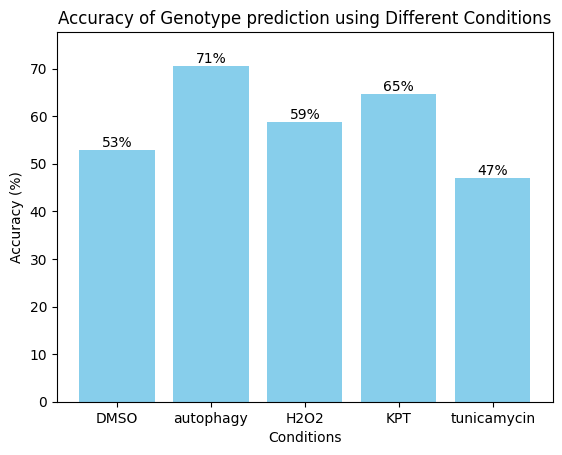

In [9]:
categories = perturbations
values = [accuracy*100 for accuracy in accuracies]

# Create the bar plot
fig, ax = plt.subplots()
# 'bars' is a BarContainer object, necessary for ax.bar_label()
bars = ax.bar(categories, values, color='skyblue')

# Add labels to the bars
ax.bar_label(bars, fmt="%.0f%%")

# Add additional plot customizations
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Conditions')
ax.set_title('Accuracy of Genotype prediction using Different Conditions')
# Adjust the y-axis limit to ensure labels fit within the plot area
ax.set_ylim(0, max(values) * 1.1)

# Display the plot
plt.show()


In [9]:
perturbations=["DMSO","autophagy", "H2O2", "KPT", "tunicamycin"]
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
accuracies = []
for perturbation in perturbations:
    num_correct= 0
    total = 0
    
    for genotype in genotype_list:
        num_correct = 0
        total=0
        for line in line_list_dict[genotype]:
            LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
            PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
            predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
            predicted_genotype= predictions[-1:]["prediction"].item()
            if(predicted_genotype=="sALS with NuP defects"):
                predicted_genotype= "sALS"
            actual_genotype = genotype_dict[line]
            if(predicted_genotype==actual_genotype):
                num_correct+=1
            total+=1
        print(perturbation, " ", genotype,": ", num_correct/total)
    accuracies.append(num_correct/total)
    print("condition",perturbation, " accuracy: ", num_correct/total )



DMSO   C9 :  0.5
DMSO   Ctrl :  0.4
DMSO   SOD1 :  0.75
DMSO   sALS :  0.5
condition DMSO  accuracy:  0.5
autophagy   C9 :  0.75
autophagy   Ctrl :  0.6
autophagy   SOD1 :  0.75
autophagy   sALS :  0.75
condition autophagy  accuracy:  0.75
H2O2   C9 :  0.25
H2O2   Ctrl :  0.4
H2O2   SOD1 :  0.75
H2O2   sALS :  1.0
condition H2O2  accuracy:  1.0
KPT   C9 :  0.25
KPT   Ctrl :  0.8
KPT   SOD1 :  0.75
KPT   sALS :  0.75
condition KPT  accuracy:  0.75
tunicamycin   C9 :  0.0
tunicamycin   Ctrl :  0.6
tunicamycin   SOD1 :  0.5
tunicamycin   sALS :  0.75
condition tunicamycin  accuracy:  0.75


DMSO   C9 :  0.5
DMSO   Ctrl :  0.4
DMSO   SOD1 :  0.75
DMSO   sALS :  0.5
autophagy   C9 :  0.75
autophagy   Ctrl :  0.6
autophagy   SOD1 :  0.75
autophagy   sALS :  0.75
H2O2   C9 :  0.25
H2O2   Ctrl :  0.4
H2O2   SOD1 :  0.75
H2O2   sALS :  1.0
KPT   C9 :  0.25
KPT   Ctrl :  0.8
KPT   SOD1 :  0.75
KPT   sALS :  0.75
tunicamycin   C9 :  0.0
tunicamycin   Ctrl :  0.6
tunicamycin   SOD1 :  0.5
tunicamycin   sALS :  0.75


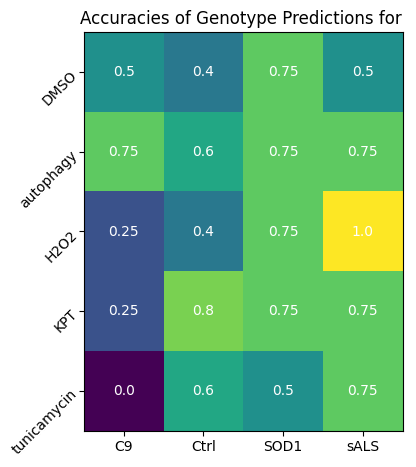

In [19]:

accuracies = np.zeros((len(perturbations),len(class_names)),float)

for p_idx,perturbation in enumerate(perturbations):
    num_correct= 0
    total = 0
    
    for g_idx,genotype in enumerate(genotype_list):
        num_correct = 0
        total=0
        for line in line_list_dict[genotype]:
            LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
            PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
            predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
            predicted_genotype= predictions[-1:]["prediction"].item()
            if(predicted_genotype=="sALS with NuP defects"):
                predicted_genotype= "sALS"
            actual_genotype = genotype_dict[line]
            if(predicted_genotype==actual_genotype):
                num_correct+=1
            total+=1
        accuracies[p_idx,g_idx] = (num_correct/total)
        print(perturbation, " ", genotype,": ", num_correct/total)

fig, ax = plt.subplots()
im = ax.imshow(accuracies)

# Show all ticks and label them with the respective list entries
ax.set_yticks(range(len(perturbations)), labels=perturbations,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_xticks(range(len(class_names)), labels=class_names)

# Loop over data dimensions and create text annotations.
for i in range(len(perturbations)):
    for j in range(len(class_names)):
        text = ax.text(j, i, accuracies[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Accuracies of Genotype Predictions for ")
fig.tight_layout()
plt.show()

DMSO   C9 :  0.5
DMSO   Ctrl :  0.4
DMSO   SOD1 :  0.75
DMSO   sALS :  0.5
autophagy   C9 :  0.75
autophagy   Ctrl :  0.6
autophagy   SOD1 :  0.75
autophagy   sALS :  0.75
H2O2   C9 :  0.25
H2O2   Ctrl :  0.4
H2O2   SOD1 :  0.75
H2O2   sALS :  1.0
KPT   C9 :  0.25
KPT   Ctrl :  0.8
KPT   SOD1 :  0.75
KPT   sALS :  0.75
tunicamycin   C9 :  0.0
tunicamycin   Ctrl :  0.6
tunicamycin   SOD1 :  0.5
tunicamycin   sALS :  0.75


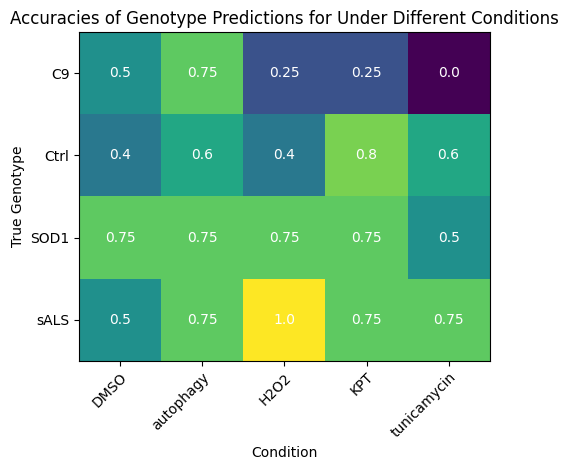

In [26]:

accuracies = np.zeros((len(class_names),len(perturbations)),float)

for p_idx,perturbation in enumerate(perturbations):
    num_correct= 0
    total = 0
    
    for g_idx,genotype in enumerate(genotype_list):
        num_correct = 0
        total=0
        for line in line_list_dict[genotype]:
            LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
            PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
            predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
            predicted_genotype= predictions[-1:]["prediction"].item()
            if(predicted_genotype=="sALS with NuP defects"):
                predicted_genotype= "sALS"
            actual_genotype = genotype_dict[line]
            if(predicted_genotype==actual_genotype):
                num_correct+=1
            total+=1
        accuracies[g_idx,p_idx] = (num_correct/total)
        print(perturbation, " ", genotype,": ", num_correct/total)

fig, ax = plt.subplots()
im = ax.imshow(accuracies)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(perturbations)), labels=perturbations,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(class_names)), labels=class_names)

# Loop over data dimensions and create text annotations.
for i in range(len(class_names)):
    for j in range(len(perturbations)):
        text = ax.text(j, i, accuracies[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Accuracies of Genotype Predictions for Under Different Conditions")
plt.xlabel("Condition")
plt.ylabel("True Genotype")

fig.tight_layout()
plt.show()

In [ ]:
categories = perturbations
values = [accuracy*100 for accuracy in accuracies]

# Create the bar plot
fig, ax = plt.subplots()
# 'bars' is a BarContainer object, necessary for ax.bar_label()
bars = ax.bar(categories, values, color='skyblue')

# Add labels to the bars
ax.bar_label(bars, fmt="%.0f%%")

# Add additional plot customizations
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Conditions')
ax.set_title('Accuracy of Genotype prediction using Different Conditions')
# Adjust the y-axis limit to ensure labels fit within the plot area
ax.set_ylim(0, max(values) * 1.1)

# Display the plot
plt.show()

In [39]:
print(genotype_list_dict)

{'Ctrl': [0, 0, 2, 2, 1, 0], 'SOD1': [0, 1, 0, 1, 0, 2], 'C9': [0, 2, 1, 1, 0, 0], 'sALS with NuP defects': [0, 1, 0, 0, 1, 2]}


In [46]:
x = ["0","1", "2", "3", "4", "5"]

In [42]:
genotypes

['Ctrl', 'SOD1', 'C9', 'sALS with NuP defects']

In [50]:
from matplotlib.ticker import MaxNLocator

[0 0 2 2 1 0]
['0', '1', '2', '3', '4', '5']


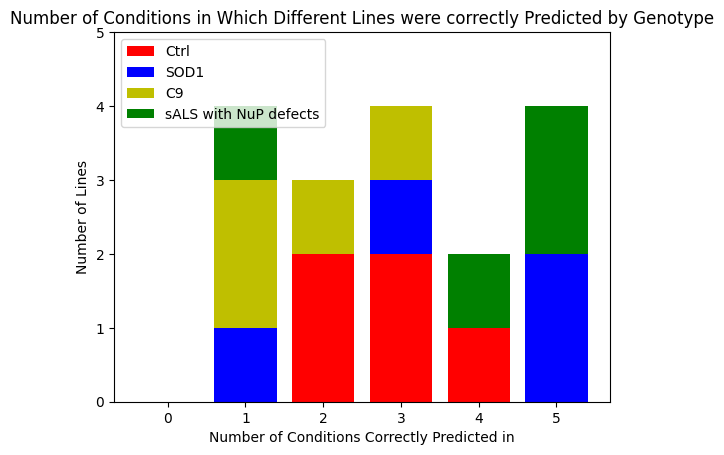

In [52]:
y1 = np.array(genotype_list_dict["Ctrl"])
y2 = np.array(genotype_list_dict["SOD1"])
y3 = np.array(genotype_list_dict["C9"])
y4 = np.array(genotype_list_dict["sALS with NuP defects"])
ax = plt.figure().gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim([0, 5])
print(y1)
print(x)
plt.bar(x, y1, color='r')
plt.bar(x, y2, bottom=y1, color='b')
plt.bar(x, y3, bottom=y1+y2, color='y')
plt.bar(x, y4, bottom=y1+y2+y3, color='g')
plt.xlabel("Number of Conditions Correctly Predicted in")
plt.ylabel("Number of Lines")
plt.legend(genotypes)

plt.title("Number of Conditions in Which Different Lines were correctly Predicted by Genotype")
plt.show()


      epoch             prediction  correct    tie       line
1500    300  sALS with NuP defects        0  False  RFTiALS#1
1501    300                   SOD1        0  False  AE8iCTR#1
1502    300  sALS with NuP defects        0  False  ZKZiCTR#1
1503    300  sALS with NuP defects        0  False  TJViALS#1
1504    300                   SOD1        0  False  XH7iCTR#1
      epoch prediction  correct    tie       line
1500    300       Ctrl        1  False  AE8iCTR#2
1501    300         C9        0  False  BFUiALS#2
1502    300       Ctrl        0  False  KRCiALS#2
1503    300         C9        0  False  XH7iCTR#2
1504    300       Ctrl        1  False  ZKZiCTR#2
      epoch prediction  correct    tie       line
1800    300       Ctrl        1  False  ADKiCTR#3
1801    300         C9        0  False  ZLMiALS#3
1802    300         C9        0  False  BFUiALS#3
1803    300         C9        0  False  NK3iCTR#3
1804    300         C9        0  False  ZKZiCTR#3
1805    300         C9      

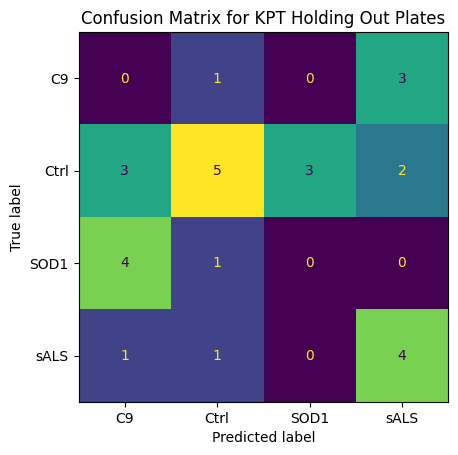

In [ ]:
perturbation="KPT"
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
plates = ["1","2","3","4","15", "16"]


for plate in plates:
    LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/platesep_finetune_"+perturbation+"_only/"+ plate
    PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
    predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie","line"])
    predictions =predictions.loc[predictions['epoch'] == 300]
    print(predictions)
    
    for index, row in predictions.iterrows():
        predicted_genotype= row["prediction"]
        if(predicted_genotype=="sALS with NuP defects"):
            predicted_genotype= "sALS"
        predicted.append(predicted_genotype)
        line = row["line"].split("#")[0]
        actual_genotype = genotype_dict[line]
        actual.append(actual_genotype)
        
        
print(predicted)
print(actual)
# 5. Compute the confusion matrix
cm = confusion_matrix(actual, predicted)

# 6. Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot(colorbar=False)
plt.title("Confusion Matrix for " + perturbation + " Holding Out Plates")
plt.show()



In [ ]:
perturbation="KPT"
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
plates = ["1","2","3","4","15", "16"]
for plate in plates:
    LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/platesep_finetune_"+perturbation+"_only/"+ plate
    PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
    predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie","line"])
    predictions =predictions.loc[predictions['epoch'] == 300]
    print(predictions)
    
    for index, row in predictions.iterrows():
        predicted_genotype= row["prediction"]
        if(predicted_genotype=="sALS with NuP defects"):
            predicted_genotype= "sALS"
        predicted.append(predicted_genotype)
        line = row["line"].split("#")[0]
        actual_genotype = genotype_dict[line]
        actual.append(actual_genotype)
        
        
print(predicted)
print(actual)
# 5. Compute the confusion matrix
cm = confusion_matrix(actual, predicted)

# 6. Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot(colorbar=False)
plt.title("Confusion Matrix for " + perturbation + " Holding Out Plates")
plt.show()



In [ ]:

accuracies = np.zeros((len(class_names),len(perturbations)),float)

for p_idx,perturbation in enumerate(perturbations):
    num_correct= 0
    total = 0
    
    for g_idx,genotype in enumerate(genotype_list):
        num_correct = 0
        total=0
        for line in line_list_dict[genotype]:
            LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
            PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
            predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
            predicted_genotype= predictions[-1:]["prediction"].item()
            if(predicted_genotype=="sALS with NuP defects"):
                predicted_genotype= "sALS"
            actual_genotype = genotype_dict[line]
            if(predicted_genotype==actual_genotype):
                num_correct+=1
            total+=1
        accuracies[g_idx,p_idx] = (num_correct/total)
        print(perturbation, " ", genotype,": ", num_correct/total)

fig, ax = plt.subplots()
im = ax.imshow(accuracies)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(perturbations)), labels=perturbations,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(class_names)), labels=class_names)

# Loop over data dimensions and create text annotations.
for i in range(len(class_names)):
    for j in range(len(perturbations)):
        text = ax.text(j, i, accuracies[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Accuracies of Genotype Predictions for Under Different Conditions")
plt.xlabel("Condition")
plt.ylabel("True Genotype")

fig.tight_layout()
plt.show()

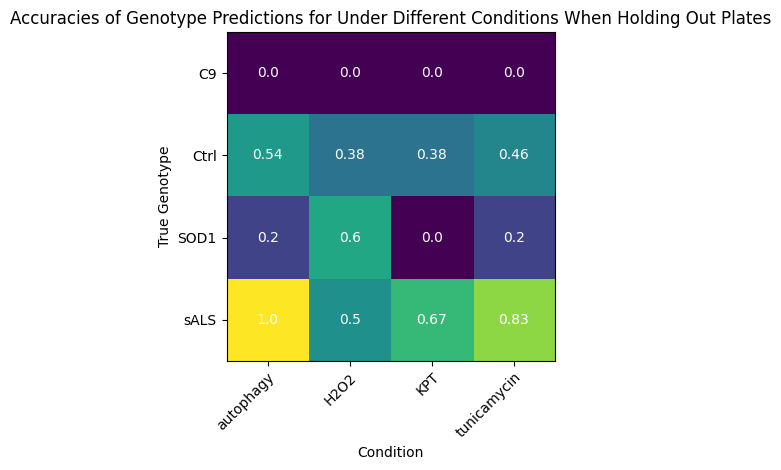

In [44]:

#accuracies by line held out
perturbations=["autophagy", "H2O2", "KPT", "tunicamycin"]

corrects = np.zeros((len(class_names),len(perturbations)),float)
totals = np.zeros((len(class_names),len(perturbations)),float)
for p_idx,perturbation in enumerate(perturbations):
    for plate in plates:
        LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/platesep_finetune_"+perturbation+"_only/"+ plate
        PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
        predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie","line"])
        predictions =predictions.loc[predictions['epoch'] == 300]
        
        for index, row in predictions.iterrows():
            predicted_genotype= row["prediction"]
            if(predicted_genotype=="sALS with NuP defects"):
                predicted_genotype= "sALS"
            line = row["line"].split("#")[0]
            actual_genotype = genotype_dict[line]
            g_idx = class_names.index(actual_genotype)
            if(predicted_genotype==actual_genotype):
                corrects[g_idx,p_idx]+=1
            totals[g_idx,p_idx] += 1


  
    
accuracies=corrects/totals
accuracies = np.round(accuracies, decimals=2)
fig, ax = plt.subplots()
im = ax.imshow(accuracies)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(perturbations)), labels=perturbations,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(class_names)), labels=class_names)

# Loop over data dimensions and create text annotations.
for i in range(len(class_names)):
    for j in range(len(perturbations)):
        text = ax.text(j, i, accuracies[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Accuracies of Genotype Predictions for Under Different Conditions When Holding Out Plates")
plt.xlabel("Condition")
plt.ylabel("True Genotype")

fig.tight_layout()
plt.show()

In [45]:
accuracies_platesep = np.sum(corrects,axis=0)/np.sum(totals,axis=0)

In [46]:
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
accuracies = []
for perturbation in perturbations:
    num_correct= 0
    total = 0
    for line in lines:
        LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
        PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
        predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
        predicted_genotype= predictions[-1:]["prediction"].item()
        if(predicted_genotype=="sALS with NuP defects"):
            predicted_genotype= "sALS"
        actual_genotype = genotype_dict[line]
        if(predicted_genotype==actual_genotype):
            num_correct+=1
        total+=1
    accuracies.append(num_correct/total)
    print("condition",perturbation, " accuracy: ", num_correct/total )

condition autophagy  accuracy:  0.7058823529411765
condition H2O2  accuracy:  0.5882352941176471
condition KPT  accuracy:  0.6470588235294118
condition tunicamycin  accuracy:  0.47058823529411764


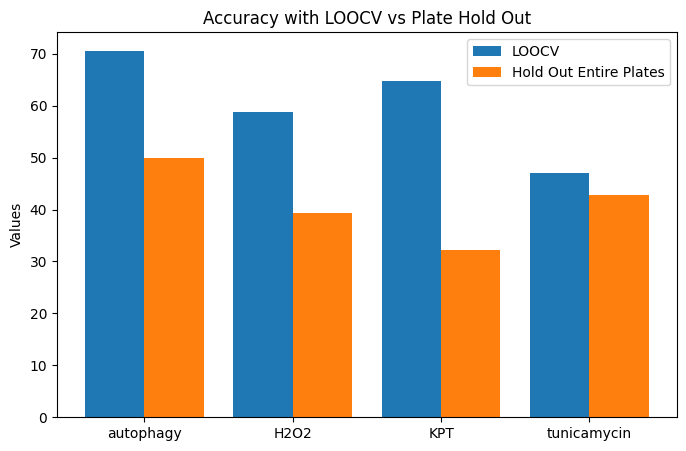

In [55]:
categories = perturbations
values = [accuracy*100 for accuracy in accuracies]
values2 = accuracies_platesep*100
# Create the bar plot
# 'bars' is a BarContainer object, necessary for ax.bar_label()
# Bar width and x-axis positions
bar_width = 0.4
x_positions = np.arange(len(categories))

# Create the plot
plt.figure(figsize=(8, 5))
plt.bar(x_positions - bar_width/2, values, bar_width, label='LOOCV')
plt.bar(x_positions + bar_width/2, values2, bar_width, label='Hold Out Entire Plates')

# Add labels to the bars
ax.bar_label(bars, fmt="%.0f%%")

# Add additional plot customizations
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Conditions')
ax.set_title('Accuracy of Genotype prediction using Different Conditions')
# Adjust the y-axis limit to ensure labels fit within the plot area
ax.set_ylim(0, max(values) * 1.1)

plt.xticks(x_positions, categories)
plt.ylabel('Values')
plt.title('Accuracy with LOOCV vs Plate Hold Out')
plt.legend()
plt.show()
# Display the plot
plt.show()


In [ ]:
perturbation="all_perturb"
predicted = []
actual = []
class_names= ["C9","Ctrl", "SOD1", "sALS"]
for line in lines:
    LINE_FOLDER = "/home/jholz/fraenkel_rotation/mcBERT-cellprofiler/0utputs/finetune_"+perturbation+"_only/"+ line
    PREDICTION_FILE = LINE_FOLDER + "/predictions.csv"
    predictions = pd.read_csv(PREDICTION_FILE, header=None, names=["epoch", "prediction", "correct", "tie"])
    predicted_genotype= predictions[-1:]["prediction"].item()
    if(predicted_genotype=="sALS with NuP defects"):
        predicted_genotype= "sALS"
    predicted.append(predicted_genotype)
    actual_genotype = genotype_dict[line]
    actual.append(actual_genotype)
print(predicted)
print(actual)
# 5. Compute the confusion matrix
cm = confusion_matrix(actual, predicted)

# 6. Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix for " + perturbation)
plt.show()
